# Klassifikation: Welche Räder müssen als Nächstes in die Werkstatt?

**Verfahren:** Klassifikation (überwachtes Lernen, Zielgröße ist eine Kategorie)  |  **Geschäftsfrage:** Welche 60 Räder soll die Werkstatt im nächsten Quartal vorsorglich prüfen?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/02_Klassifikation_Wartungsrisiko.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Die Werkstatt hat begrenzte Kapazität. Sie soll die Räder prüfen, bei denen sich das lohnt — nicht die, die zufällig oben auf der Liste stehen.

### Die Ausgangslage

VeloCity repariert heute **reaktiv**: Ein Rad fällt aus, jemand meldet es, die Werkstatt
rückt aus. Das ist teuer und ärgerlich — das Rad steht irgendwo im Stadtgebiet, ein
Kunde ist unterwegs liegengeblieben, und der Ruf leidet.

Die Werkstattleitung hat Kapazität für **60 vorsorgliche Prüfungen je Quartal** (rund
fünf pro Werktag, neben dem laufenden Betrieb). Die Frage ist nicht *ob* geprüft wird,
sondern **welche 60 Räder**.

### Warum das eine Klassifikation ist

Gefragt ist keine Zahl, sondern eine **Einteilung**: Wird dieses Rad im nächsten Quartal
eine Schadensmeldung auslösen — ja oder nein? Zwei Klassen, also Klassifikation.

> *„Bei der Klassifikation geht es darum, Elemente anhand ihrer Merkmale automatisiert in
> Klassen einzuteilen. Die Klassen sind vorgegeben, die Klassenzugehörigkeit eines
> Elements ist nicht bekannt."*
> — Provost/Fawcett, *Data Science für Unternehmen*, S. 45 f.

### Die beiden Fehlerarten sind unterschiedlich teuer

Das ist der Kern dieser Phase, und er entscheidet später über das ganze Modell:

| Fehler | Was passiert | Kosten |
|---|---|---|
| **Falsch negativ** — Modell sagt „unauffällig", das Rad fällt aber aus | Kunde bleibt liegen, Bergungsfahrt, Ersatz, Beschwerde | **180 €** |
| **Falsch positiv** — Modell sagt „prüfen", das Rad war in Ordnung | 35 Minuten Werkstattzeit umsonst | **25 €** |

**Ein verpasster Ausfall kostet gut sieben Mal so viel wie eine unnötige Prüfung.**
Ein Modell, das beide Fehler gleich behandelt, optimiert deshalb das Falsche. Wir werden
das in Phase 4 ausdrücklich einstellen müssen.

### Die Erfolgskriterien

| | Kriterium | Schwelle |
|---|---|---|
| **fachlich** | Von den 60 Rädern auf der Quartalsliste müssen mindestens 70 % tatsächlich auffällig werden | sonst verliert die Werkstatt das Vertrauen in die Liste |
| **wirtschaftlich** | Die erwarteten Kosten je Quartal müssen **unter** denen der heutigen Faustregel liegen | die Faustregel lautet: „das älteste Rad zuerst" |
| **Betrieb** | Die Liste muss ohne Nacharbeit in die Instandhaltungsansicht der Warenwirtschaft übernehmbar sein | |

Das zweite Kriterium ist das wichtigere und wird gerne vergessen: **Ein Modell muss
nicht gut sein, sondern besser als das, was heute schon getan wird.**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/")
pd.set_option("display.width", 150)

KOSTEN_VERPASST = 180.0     # falsch negativ: Ausfall auf der Strasse
KOSTEN_UNNOETIG = 25.0      # falsch positiv: Pruefung ohne Befund
KAPAZITAET = 60             # Pruefungen je Quartal
HORIZONT_TAGE = 90          # Vorhersagefenster

print(f"Ein verpasster Ausfall kostet das "
      f"{KOSTEN_VERPASST / KOSTEN_UNNOETIG:.1f}-fache einer unnötigen Prüfung.")
print(f"Kapazität: {KAPAZITAET} Räder je Quartal, Vorhersagefenster {HORIZONT_TAGE} Tage.")

Ein verpasster Ausfall kostet das 7.2-fache einer unnötigen Prüfung.
Kapazität: 60 Räder je Quartal, Vorhersagefenster 90 Tage.


---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Wie oft fallen Räder überhaupt aus, und hängt das erkennbar mit ihrer Nutzung zusammen? Ohne einen solchen Zusammenhang wäre das Projekt hier zu Ende.

In [2]:
raeder = pd.read_csv(BASIS + "fahrrad.csv", parse_dates=["angeschafft_am", "ausgemustert_am"])
schaeden = pd.read_csv(BASIS + "schadensmeldung.csv", parse_dates=["gemeldet_am"])
auftraege = pd.read_csv(BASIS + "wartungsauftrag.csv", parse_dates=["eroeffnet_am", "erledigt_am"])
fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])

print(f"Räder:              {len(raeder):>6d}   davon ausgemustert: {(raeder.status=='ausgemustert').sum()}")
print(f"Schadensmeldungen:  {len(schaeden):>6d}")
print(f"Wartungsaufträge:   {len(auftraege):>6d}")
print(f"Fahrten:            {len(fahrten):>6d}")
print(f"\nZeitraum der Meldungen: {schaeden.gemeldet_am.min().date()} bis {schaeden.gemeldet_am.max().date()}")
print("\nSchwere der Meldungen:")
print(schaeden.schwere.value_counts().to_string())
print("\nHäufigste Kategorien:")
print(schaeden.kategorie.value_counts().head(5).to_string())

Räder:                 240   davon ausgemustert: 12
Schadensmeldungen:     735
Wartungsaufträge:      735
Fahrten:             60124

Zeitraum der Meldungen: 2023-09-02 bis 2026-08-24

Schwere der Meldungen:
schwere
fahruntauglich    297
mittel            248
leicht            190

Häufigste Kategorien:
kategorie
Licht                 115
Sattel/Sitzhaltung    112
Reifen/Platten        102
Bremse                101
Schaltung             101


### 2.1 Wie verteilen sich die Meldungen auf die Flotte?

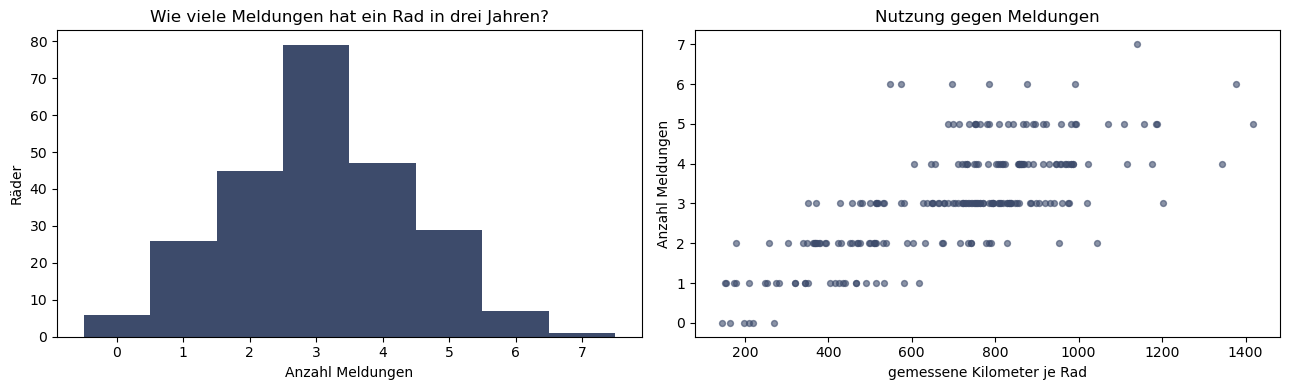

Korrelation Kilometer <-> Meldungen: r = 0.725
Meldungen je Rad: Mittel 3.1, Median 3, Maximum 7


In [3]:
je_rad = schaeden.groupby("fahrrad_id").size().reindex(raeder.fahrrad_id, fill_value=0)

fig, achsen = plt.subplots(1, 2, figsize=(13, 4))
achsen[0].hist(je_rad, bins=range(0, int(je_rad.max()) + 2), color="#3d4b6b", align="left")
achsen[0].set_title("Wie viele Meldungen hat ein Rad in drei Jahren?")
achsen[0].set_xlabel("Anzahl Meldungen"); achsen[0].set_ylabel("Räder")

nutzung = fahrten[fahrten.status == "abgeschlossen"].groupby("fahrrad_id").agg(
    fahrten_gesamt=("ausleihe_id", "size"),
    km_gesamt=("distanz_km", "sum"),
)
verbund = raeder.set_index("fahrrad_id").join(nutzung).join(je_rad.rename("meldungen"))
verbund["fahrten_gesamt"] = verbund.fahrten_gesamt.fillna(0)

achsen[1].scatter(verbund.km_gesamt, verbund.meldungen, s=18, alpha=.6, color="#3d4b6b")
achsen[1].set_xlabel("gemessene Kilometer je Rad"); achsen[1].set_ylabel("Anzahl Meldungen")
achsen[1].set_title("Nutzung gegen Meldungen")
plt.tight_layout(); plt.show()

r = verbund[["km_gesamt", "meldungen"]].corr().iloc[0, 1]
print(f"Korrelation Kilometer <-> Meldungen: r = {r:.3f}")
print(f"Meldungen je Rad: Mittel {je_rad.mean():.1f}, Median {je_rad.median():.0f}, "
      f"Maximum {je_rad.max()}")

**Der Zusammenhang ist da, aber er ist nicht perfekt** — und genau so soll es sein. Bei
r ≈ 0,7 gibt es viel gemeinsame Bewegung und trotzdem Räder, die viel gefahren wurden
und selten melden, und umgekehrt. Wäre r = 0,99, bräuchte man kein Modell, sondern eine
Sortierung nach Kilometern. Wäre r = 0,1, wäre nichts zu lernen.

### 2.2 Die entscheidende Frage der Datenaufbereitung: Wann fragen wir?

In [4]:
# Wieviele Raeder melden sich in einem 90-Tage-Fenster?
ende = fahrten.startzeit.max().normalize()
stichtag = ende - pd.Timedelta(days=HORIZONT_TAGE)
im_bestand = raeder[(raeder.angeschafft_am <= stichtag)
                    & (raeder.ausgemustert_am.isna() | (raeder.ausgemustert_am > stichtag))]
melden = set(schaeden[schaeden.gemeldet_am > stichtag].fahrrad_id)
positiv = im_bestand.fahrrad_id.isin(melden)

print(f"Stichtag: {stichtag.date()}, Fenster bis {ende.date()}")
print(f"Räder im Bestand:             {len(im_bestand)}")
print(f"davon mit Meldung im Fenster: {positiv.sum()}  ({positiv.mean():.1%})")
print(f"\nWerkstattkapazität {KAPAZITAET} von {len(im_bestand)} Rädern "
      f"= {KAPAZITAET/len(im_bestand):.0%} der Flotte")

Stichtag: 2026-05-26, Fenster bis 2026-08-24
Räder im Bestand:             228
davon mit Meldung im Fenster: 112  (49.1%)

Werkstattkapazität 60 von 228 Rädern = 26% der Flotte


Rund **47 % der Räder** melden sich in einem Quartal — die Klassen sind also gut besetzt.
Aber die Werkstatt kann nur **26 % der Flotte** prüfen. Das Modell muss also nicht nur
richtig liegen, sondern **priorisieren**: Es muss sagen, welche Räder am dringendsten
sind, nicht nur welche überhaupt auffällig werden. Darauf kommen wir in Phase 5 zurück.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Wir bauen eine Tabelle, in der jede Zeile eine **Frage zu einem Zeitpunkt** ist: „Rad 47, Stand 1. April — meldet es sich bis zum 30. Juni?"

### 3.1 Der häufigste Fehler bei Wartungsvorhersagen

Man nimmt jedes Rad, zählt seine Kilometer **über den gesamten Zeitraum** und fragt: hat
es je eine Meldung gehabt? Das ergibt eine schöne Tabelle — und ein wertloses Modell.

**Warum:** Die Kilometer eines Rades, das im Januar ausfiel, enthalten auch die
Kilometer *nach* dem Januar. Das Modell lernt aus der Zukunft. Und die Frage „hat es je
gemeldet?" hilft der Werkstatt nicht, denn sie plant *das nächste Quartal*.

**Richtig ist ein Schnitt in der Zeit:**

```
   Merkmale               Stichtag              Label
   ├──── 180 Tage ────────┤                      │
   Fahrten, km, frühere   │  ←→  90 Tage  →  Meldung ja/nein
   Meldungen ...          │
```

Alles links vom Stichtag darf ins Modell. Alles rechts davon ist das, was vorhergesagt
werden soll — und muss beim Rechnen unsichtbar bleiben.

### 3.2 Die Frage mehrfach stellen

Ein einziger Stichtag ergäbe 228 Zeilen — zu wenig. Wir stellen dieselbe Frage deshalb
zu **mehreren Zeitpunkten**, im Abstand eines Quartals. Jedes Rad taucht dann mehrfach
auf, aber mit *unterschiedlichem* Wissensstand und *unterschiedlichem* Ausgang. Das ist
kein Trick, sondern genau die Art, wie solche Modelle in der Praxis gebaut werden.

In [5]:
abgeschlossen = fahrten[fahrten.status == "abgeschlossen"].copy()
abgeschlossen["dauer_min"] = (abgeschlossen.endzeit - abgeschlossen.startzeit).dt.total_seconds() / 60

# DIE SENSORLUECKE SCHLIESSEN
# distanz_km fehlt bei 42 Prozent der Fahrten. Wer einfach aufsummiert, misst
# nicht die Nutzung, sondern die Verfuegbarkeit des Sensors - und zwar je Rad
# unterschiedlich stark. Wir schaetzen die Strecke stattdessen aus Dauer und
# typischer Geschwindigkeit. Verschlissen wird auch, wenn niemand misst.
TYPISCHE_GESCHWINDIGKEIT = {"CITY": 13.0, "EBIKE": 18.0, "CARGO": 11.0}   # km/h
abgeschlossen = abgeschlossen.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
abgeschlossen["km_schaetz"] = (abgeschlossen.dauer_min / 60.0
                               * abgeschlossen.typ_code.map(TYPISCHE_GESCHWINDIGKEIT))

gemessen = abgeschlossen.dropna(subset=["distanz_km"])
abweichung = (gemessen.km_schaetz - gemessen.distanz_km).abs().mean()
print(f"Wo beides vorliegt, weicht die Schätzung im Mittel um {abweichung:.2f} km ab")
print(f"(mittlere gemessene Strecke: {gemessen.distanz_km.mean():.2f} km)")

RUECKBLICK_TAGE = 180

def zeile_bauen(stichtag):
    """Eine Momentaufnahme der Flotte: Merkmale aus der Vergangenheit, Label aus der Zukunft."""
    bestand = raeder[(raeder.angeschafft_am <= stichtag - pd.Timedelta(days=30))
                     & (raeder.ausgemustert_am.isna() | (raeder.ausgemustert_am > stichtag))].copy()

    # --- Merkmale: NUR aus der Zeit VOR dem Stichtag
    fenster = abgeschlossen[(abgeschlossen.startzeit > stichtag - pd.Timedelta(days=RUECKBLICK_TAGE))
                            & (abgeschlossen.startzeit <= stichtag)]
    nutzung_fenster = fenster.groupby("fahrrad_id").agg(
        fahrten_180=("ausleihe_id", "size"),
        km_180=("km_schaetz", "sum"),
        dauer_mittel=("dauer_min", "mean"),
    )
    bis_jetzt = abgeschlossen[abgeschlossen.startzeit <= stichtag]
    gesamt = bis_jetzt.groupby("fahrrad_id").agg(
        fahrten_gesamt=("ausleihe_id", "size"),
        km_gesamt=("km_schaetz", "sum"),
    )
    frueher = schaeden[schaeden.gemeldet_am <= stichtag]
    meldungen_bisher = frueher.groupby("fahrrad_id").size().rename("meldungen_bisher")
    letzte = frueher.groupby("fahrrad_id").gemeldet_am.max().rename("letzte_meldung")

    # KILOMETER SEIT DER LETZTEN MELDUNG - das fachlich entscheidende Merkmal.
    # Ein Bremsbelag weiss nicht, wieviel das Rad in seinem Leben gefahren ist,
    # sondern nur, wieviel seit seinem Einbau.
    seit = bis_jetzt.merge(letzte, left_on="fahrrad_id", right_index=True, how="left")
    nach_reparatur = seit.letzte_meldung.isna() | (seit.startzeit > seit.letzte_meldung)
    km_seit = seit[nach_reparatur].groupby("fahrrad_id").km_schaetz.sum().rename("km_seit_meldung")

    z = bestand.set_index("fahrrad_id").join(
        [nutzung_fenster, gesamt, meldungen_bisher, letzte, km_seit])
    for spalte in ["fahrten_180", "km_180", "fahrten_gesamt", "km_gesamt",
                   "meldungen_bisher", "km_seit_meldung"]:
        z[spalte] = z[spalte].fillna(0)
    z["dauer_mittel"] = z.dauer_mittel.fillna(z.dauer_mittel.median())
    z["tage_im_bestand"] = (stichtag - z.angeschafft_am).dt.days
    z["tage_seit_meldung"] = (stichtag - z.letzte_meldung).dt.days.fillna(9999)
    z["km_je_tag"] = z.km_gesamt / z.tage_im_bestand.clip(lower=1)

    # --- Label: NUR aus der Zeit NACH dem Stichtag
    kuenftig = set(schaeden[(schaeden.gemeldet_am > stichtag)
                            & (schaeden.gemeldet_am <= stichtag + pd.Timedelta(days=HORIZONT_TAGE))].fahrrad_id)
    z["meldet_sich"] = z.index.isin(kuenftig).astype(int)
    z["stichtag"] = stichtag
    return z.reset_index()

stichtage = pd.date_range(end=ende - pd.Timedelta(days=HORIZONT_TAGE), periods=8, freq="90D")

panel = pd.concat([zeile_bauen(s) for s in stichtage], ignore_index=True)

print("Stichtage:", ", ".join(str(s.date()) for s in stichtage))
print(f"\nZeilen im Panel: {len(panel)}   ({len(stichtage)} Stichtage × rund "
      f"{len(panel)//len(stichtage)} Räder)")
print(f"Anteil positiver Fälle: {panel.meldet_sich.mean():.1%}")
print("\nAnteil je Stichtag:")
print(panel.groupby(panel.stichtag.dt.date).meldet_sich.agg(["size", "mean"]).round(3).to_string())

Wo beides vorliegt, weicht die Schätzung im Mittel um 0.48 km ab
(mittlere gemessene Strecke: 4.76 km)


Stichtage: 2024-09-03, 2024-12-02, 2025-03-02, 2025-05-31, 2025-08-29, 2025-11-27, 2026-02-25, 2026-05-26

Zeilen im Panel: 1686   (8 Stichtage × rund 210 Räder)
Anteil positiver Fälle: 29.4%

Anteil je Stichtag:
            size   mean
stichtag               
2024-09-03   176  0.330
2024-12-02   193  0.098
2025-03-02   209  0.230
2025-05-31   213  0.549
2025-08-29   216  0.245
2025-11-27   223  0.090
2026-02-25   228  0.303
2026-05-26   228  0.487


> **Sehen Sie sich die Spalte `mean` genau an.** Der Anteil auffälliger Räder schwankt
> zwischen rund **9 % im November und 55 % im Mai** — um den Faktor sechs. Das ist kein
> Fehler in den Daten, sondern die Jahreszeit: Im Winter wird kaum gefahren, also
> verschleißt kaum etwas, also meldet sich kaum ein Rad.
>
> Für uns hat das zwei Folgen, und beide sind unangenehm:
>
> 1. **Die Testmenge ist ein Mai-Stichtag** — ein Zeitpunkt mit hohem Anteil. Ein Modell,
>    das auf gemischten Jahreszeiten trainiert wurde, ist dort systematisch zu
>    zurückhaltend.
> 2. **Die Kapazität von 60 Rädern passt nicht zu jeder Jahreszeit.** Im November wären
>    60 Prüfungen Verschwendung, im Mai zu wenig.
>
> Wir lassen das hier so stehen und kommen am Ende darauf zurück — es ist einer der
> Punkte, an denen eine zweite Runde ansetzen müsste.

### 3.3 Aufteilen — zeitlich, nicht zufällig

In [6]:
merkmale = ["fahrten_180", "km_180", "dauer_mittel", "fahrten_gesamt", "km_gesamt",
            "meldungen_bisher", "tage_im_bestand", "tage_seit_meldung", "km_je_tag",
            "km_seit_meldung"]
typ_dummies = pd.get_dummies(panel["typ_code"], prefix="typ").astype(int)
X_alle = pd.concat([panel[merkmale], typ_dummies], axis=1)
y_alle = panel["meldet_sich"]

# Der LETZTE Stichtag ist die Testmenge - so, wie es im Betrieb waere:
# trainieren auf allem Vergangenen, anwenden auf den heutigen Stand.
letzter = stichtage[-1]
ist_test = panel.stichtag == letzter

X_train, y_train = X_alle[~ist_test], y_alle[~ist_test]
X_test, y_test = X_alle[ist_test], y_alle[ist_test]

print(f"Training: {len(X_train)} Zeilen aus {ist_test.sum() and len(stichtage)-1} Stichtagen "
      f"(bis {stichtage[-2].date()})")
print(f"Test:     {len(X_test)} Zeilen vom Stichtag {letzter.date()}")
print(f"Anteil positiv  Training {y_train.mean():.1%} | Test {y_test.mean():.1%}")

Training: 1458 Zeilen aus 7 Stichtagen (bis 2026-02-25)
Test:     228 Zeilen vom Stichtag 2026-05-26
Anteil positiv  Training 26.3% | Test 48.7%


> **Warum nicht `train_test_split` wie in Notebook 1?** Weil dasselbe Rad in mehreren
> Zeilen vorkommt. Ein zufälliger Schnitt würde Rad 47 vom Januar ins Training und Rad 47
> vom April in den Test legen — das Modell hätte das Rad dann schon gesehen und sähe
> besser aus, als es ist. Der Schnitt entlang der Zeit vermeidet das und bildet
> zusätzlich die Betriebslage ab.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Erst die Faustregel, die es zu schlagen gilt. Dann Modelle — und zwar mit eingebauter Kostenasymmetrie.

### 4.1 Die Faustregeln als Maßstab

Bevor ein Modell antritt, muss klar sein, wogegen. Drei Regeln, die eine Werkstatt ohne
jedes Modell anwenden könnte:

1. **„Das älteste Rad zuerst"** — die heutige Praxis
2. **„Das meistgefahrene Rad zuerst"** — die naheliegende Verbesserung
3. **„Das Rad mit den meisten Kilometern seit der letzten Reparatur zuerst"** — die
   Regel, die ein Werkstattmeister vorschlagen würde

Die dritte ist nicht raffinierter als die zweite, sondern **sachkundiger**. Sie steckt
kein bisschen mehr Mathematik, sondern das Wissen, dass ein Bremsbelag nicht zählt,
wieviel das Rad in seinem Leben gefahren ist, sondern nur, wieviel seit seinem Einbau.

Jede der drei liefert eine Rangfolge, und aus einer Rangfolge wird eine Liste der Top 60.

In [7]:
def liste_bewerten(name, rangfolge, y_wahr, kapazitaet=KAPAZITAET):
    """Nimmt die obersten k Raeder einer Rangfolge und rechnet nach, was das kostet."""
    reihenfolge = np.argsort(-np.asarray(rangfolge))
    gewaehlt = np.zeros(len(y_wahr), dtype=bool)
    gewaehlt[reihenfolge[:kapazitaet]] = True
    y = np.asarray(y_wahr)

    richtig_geprueft = int((gewaehlt & (y == 1)).sum())      # Ausfall verhindert
    unnoetig = int((gewaehlt & (y == 0)).sum())              # umsonst geprueft
    verpasst = int((~gewaehlt & (y == 1)).sum())             # Ausfall auf der Strasse
    kosten = verpasst * KOSTEN_VERPASST + unnoetig * KOSTEN_UNNOETIG
    return {"Vorgehen": name, "Treffer": richtig_geprueft,
            "Trefferquote": round(richtig_geprueft / kapazitaet, 3),
            "unnötig geprüft": unnoetig, "Ausfälle verpasst": verpasst,
            "Kosten (EUR)": round(kosten, 0)}

test_zeilen = panel[ist_test].reset_index(drop=True)
vergleich = []

# Nichts tun - alle Ausfaelle passieren
alle_verpasst = int(y_test.sum())
vergleich.append({"Vorgehen": "gar nicht vorsorglich prüfen", "Treffer": 0, "Trefferquote": 0.0,
                  "unnötig geprüft": 0, "Ausfälle verpasst": alle_verpasst,
                  "Kosten (EUR)": round(alle_verpasst * KOSTEN_VERPASST, 0)})
vergleich.append(liste_bewerten("Faustregel: ältestes Rad zuerst",
                                test_zeilen.tage_im_bestand.values, y_test))
vergleich.append(liste_bewerten("Faustregel: meiste Kilometer gesamt",
                                test_zeilen.km_gesamt.values, y_test))
vergleich.append(liste_bewerten("Faustregel: km seit letzter Meldung",
                                test_zeilen.km_seit_meldung.values, y_test))
print(pd.DataFrame(vergleich).to_string(index=False))

                           Vorgehen  Treffer  Trefferquote  unnötig geprüft  Ausfälle verpasst  Kosten (EUR)
       gar nicht vorsorglich prüfen        0         0.000                0                111       19980.0
    Faustregel: ältestes Rad zuerst       23         0.383               37                 88       16765.0
Faustregel: meiste Kilometer gesamt       33         0.550               27                 78       14715.0
Faustregel: km seit letzter Meldung       48         0.800               12                 63       11640.0


**Diese Tabelle ist der Kern des ganzen Notebooks — lesen Sie sie langsam.**

Von der ersten zur zweiten Regel gewinnt man ein paar Punkte. Von der zweiten zur dritten
springt die Trefferquote um mehr als zwanzig. Und zwischen diesen beiden Regeln liegt
**kein einziger Rechenschritt Unterschied** — nur ein anderes Verständnis davon, wie
Verschleiß entsteht.

Merken Sie sich diese Zahlen. Wir kommen in Phase 5 darauf zurück, wenn das Modell
gerechnet hat.

### 4.2 Entscheidungsbaum — mit Gewichtung der Klassen

Klassengewichte: {0: 1.0, 1: 7.2}


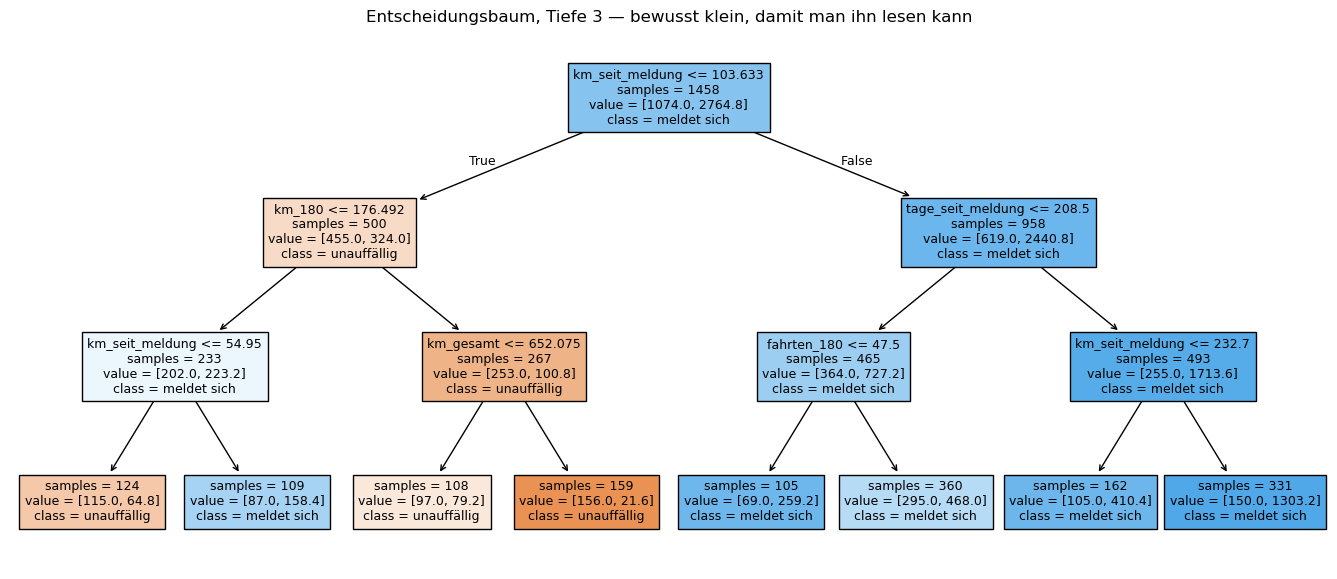

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# class_weight uebersetzt die Kostenasymmetrie aus Phase 1 in das Modell:
# ein verpasster Ausfall wiegt gut sieben unnoetige Pruefungen auf.
gewichte = {0: 1.0, 1: KOSTEN_VERPASST / KOSTEN_UNNOETIG}
print("Klassengewichte:", {k: round(v, 1) for k, v in gewichte.items()})

baum = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40,
                              class_weight=gewichte, random_state=42)
baum.fit(X_train, y_train)

plt.figure(figsize=(17, 7))
plot_tree(baum, feature_names=list(X_alle.columns),
          class_names=["unauffällig", "meldet sich"], filled=True, fontsize=9, impurity=False)
plt.title("Entscheidungsbaum, Tiefe 3 — bewusst klein, damit man ihn lesen kann")
plt.show()

**Einen Baum kann man vorlesen.** Genau das macht ihn für den Einstieg so wertvoll und
in der Praxis so überzeugend: Die Werkstattleitung sieht, *warum* ein Rad auf der Liste
steht, und kann widersprechen. Bei einem Random Forest oder einem neuronalen Netz geht
das nicht mehr.

Die oberste Verzweigung ist die wichtigste Frage, die das Modell stellt. Sehen Sie nach,
welches Merkmal dort steht.

### 4.3 Random Forest

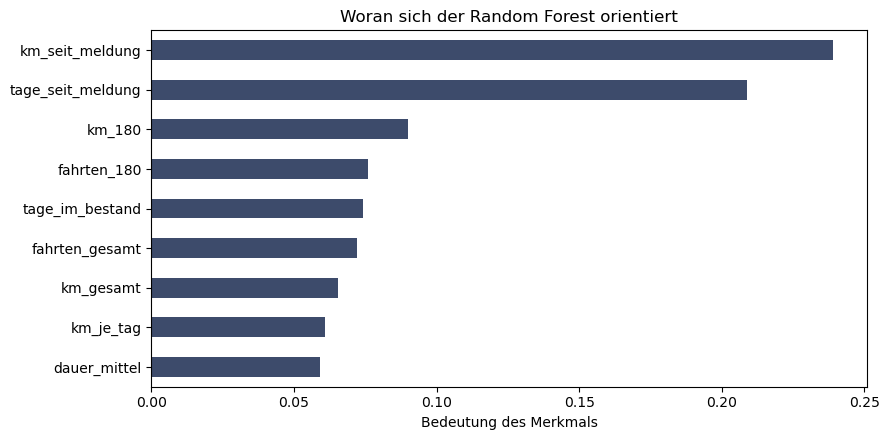

km_seit_meldung      0.239
tage_seit_meldung    0.209
km_180               0.090
fahrten_180          0.076
tage_im_bestand      0.074
fahrten_gesamt       0.072
km_gesamt            0.066
km_je_tag            0.061
dauer_mittel         0.059
meldungen_bisher     0.022
typ_CITY             0.020
typ_EBIKE            0.008
typ_CARGO            0.004


In [9]:
wald = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                              class_weight=gewichte, random_state=42, n_jobs=-1)
wald.fit(X_train, y_train)

wichtigkeit = pd.Series(wald.feature_importances_, index=X_alle.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 4.5))
wichtigkeit.head(9).iloc[::-1].plot(kind="barh", color="#3d4b6b")
plt.title("Woran sich der Random Forest orientiert"); plt.xlabel("Bedeutung des Merkmals")
plt.tight_layout(); plt.show()
print(wichtigkeit.round(3).to_string())

> **Vorsicht bei der Deutung.** „Bedeutung des Merkmals" heißt hier: wie oft und wie
> wirksam der Wald an diesem Merkmal aufgeteilt hat. Das ist **keine Ursache-Wirkung**.
> Dass `tage_seit_meldung` weit oben steht, heißt nicht, dass langes Schweigen einen
> Defekt verursacht — es heißt, dass dieses Merkmal die Räder gut trennt.

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Confusion-Matrix, Kosten und die Frage, ob wir die Faustregel überhaupt schlagen.

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

for name, modell in [("Entscheidungsbaum", baum), ("Random Forest", wald)]:
    wahrscheinlichkeit = modell.predict_proba(X_test)[:, 1]
    vergleich.append(liste_bewerten(f"Modell: {name}", wahrscheinlichkeit, y_test))

tabelle = pd.DataFrame(vergleich)
print(tabelle.to_string(index=False))

bestes = tabelle.loc[tabelle["Kosten (EUR)"].idxmin(), "Vorgehen"]
ersparnis = tabelle["Kosten (EUR)"].iloc[0] - tabelle["Kosten (EUR)"].min()
print(f"\nGünstigstes Vorgehen: {bestes}")
print(f"Ersparnis gegenüber 'gar nicht prüfen': {ersparnis:,.0f} EUR je Quartal".replace(",", "."))

                           Vorgehen  Treffer  Trefferquote  unnötig geprüft  Ausfälle verpasst  Kosten (EUR)
       gar nicht vorsorglich prüfen        0         0.000                0                111       19980.0
    Faustregel: ältestes Rad zuerst       23         0.383               37                 88       16765.0
Faustregel: meiste Kilometer gesamt       33         0.550               27                 78       14715.0
Faustregel: km seit letzter Meldung       48         0.800               12                 63       11640.0
          Modell: Entscheidungsbaum       44         0.733               16                 67       12460.0
              Modell: Random Forest       49         0.817               11                 62       11435.0

Günstigstes Vorgehen: Modell: Random Forest
Ersparnis gegenüber 'gar nicht prüfen': 8.545 EUR je Quartal


### 5.1 Die Confusion-Matrix — welche Art Fehler macht das Modell?

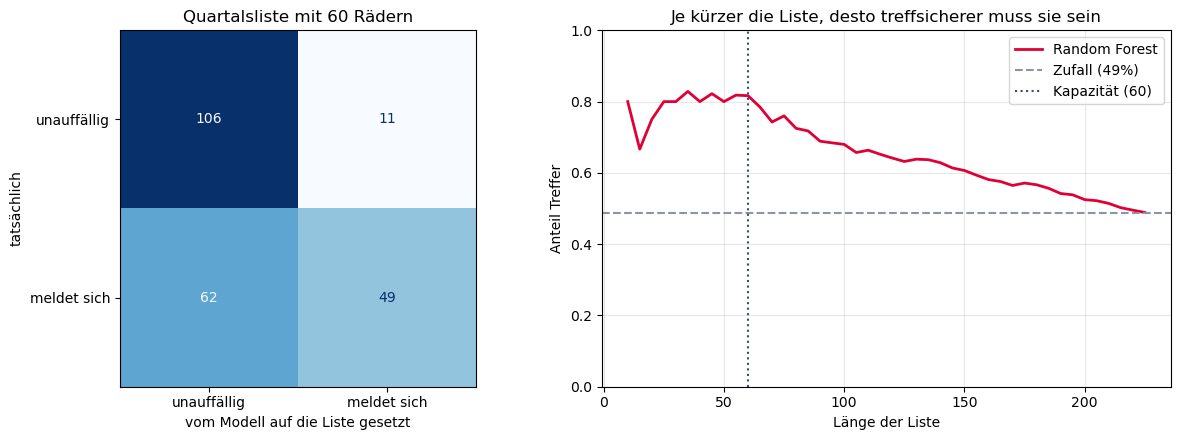

              precision    recall  f1-score   support

 unauffällig      0.631     0.906     0.744       117
 meldet sich      0.817     0.441     0.573       111

    accuracy                          0.680       228
   macro avg      0.724     0.674     0.658       228
weighted avg      0.721     0.680     0.661       228



In [11]:
p_wald = wald.predict_proba(X_test)[:, 1]
reihenfolge = np.argsort(-p_wald)
auf_liste = np.zeros(len(y_test), dtype=bool)
auf_liste[reihenfolge[:KAPAZITAET]] = True

cm = confusion_matrix(y_test, auf_liste.astype(int))
fig, achsen = plt.subplots(1, 2, figsize=(12.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["unauffällig", "meldet sich"]).plot(
    cmap="Blues", ax=achsen[0], colorbar=False)
achsen[0].set_title(f"Quartalsliste mit {KAPAZITAET} Rädern")
achsen[0].set_xlabel("vom Modell auf die Liste gesetzt"); achsen[0].set_ylabel("tatsächlich")

# Wie gut ist die Rangfolge? Trefferquote in Abhaengigkeit der Listenlaenge.
laengen = range(10, len(y_test) + 1, 5)
quoten = []
for k in laengen:
    gew = np.zeros(len(y_test), dtype=bool); gew[reihenfolge[:k]] = True
    quoten.append((np.asarray(y_test)[gew] == 1).mean())
achsen[1].plot(list(laengen), quoten, color="#e00034", lw=2, label="Random Forest")
achsen[1].axhline(float(y_test.mean()), color="#8c95a8", ls="--",
                  label=f"Zufall ({y_test.mean():.0%})")
achsen[1].axvline(KAPAZITAET, color="#3d4b6b", ls=":", label=f"Kapazität ({KAPAZITAET})")
achsen[1].set_xlabel("Länge der Liste"); achsen[1].set_ylabel("Anteil Treffer")
achsen[1].set_title("Je kürzer die Liste, desto treffsicherer muss sie sein")
achsen[1].legend(); achsen[1].grid(alpha=.3); achsen[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

print(classification_report(y_test, auf_liste.astype(int),
                            target_names=["unauffällig", "meldet sich"], digits=3))

### 5.2 Was das Modell wirklich beigetragen hat

Vergleichen Sie die vier Zeilen der Tabelle oben noch einmal, und zwar in dieser
Reihenfolge:

| Vorgehen | Woher der Fortschritt kommt |
|---|---|
| ältestes Rad zuerst | — |
| meiste Kilometer gesamt | eine bessere Kennzahl |
| **km seit letzter Meldung** | **Sachverstand: Verschleiß zählt ab der Reparatur** |
| Random Forest | Feinschliff auf das, was die dritte Regel schon leistet |

**Der große Sprung liegt vor dem Modell, nicht im Modell.** Wer bei „meiste Kilometer"
stehengeblieben wäre und dann ein neuronales Netz darauf geworfen hätte, wäre schlechter
gefahren als jemand, der eine Viertelstunde mit dem Werkstattmeister gesprochen hat.

Das ist keine Kritik am maschinellen Lernen. Es ist die Erklärung, warum CRISP-DM mit
**Business Understanding** anfängt und nicht mit *Modeling* — und warum in dieser Phase
die Fachleute im Raum sitzen müssen.

Der Random Forest verdient trotzdem seinen Platz: Er hat die dritte Regel nicht bekommen,
er hat sie **gefunden** — sehen Sie sich noch einmal an, welches Merkmal in der
Bedeutungsgrafik oben ganz oben steht. Bei einer Aufgabe, bei der niemand die richtige
Regel kennt, ist genau das sein Wert.

### 5.3 Wie gut ist die Liste, die die Werkstatt bekommt?

Das rechte Bild beantwortet die Frage, die die Werkstattleitung wirklich stellt.

Die Kurve fällt nach rechts ab, und das ist genau richtig: Die ersten Räder auf der Liste
sind die sichersten Fälle. Je länger man die Liste macht, desto mehr Wackelkandidaten
kommen dazu. Bei der Kapazität von 60 lesen Sie ab, welchen Anteil Treffer die Liste
enthält — und der Abstand zur grauen Zufallslinie ist der Wert des Modells.

### 5.4 Bewertung gegen die Erfolgskriterien aus Phase 1

In [12]:
trefferquote = float((np.asarray(y_test)[auf_liste] == 1).mean())
kosten_modell = float(tabelle.loc[tabelle.Vorgehen == "Modell: Random Forest", "Kosten (EUR)"].iloc[0])
kosten_faustregel = float(tabelle.loc[tabelle.Vorgehen.str.contains("ältestes"), "Kosten (EUR)"].iloc[0])

print("Erfolgskriterien aus Phase 1:\n")
k1 = trefferquote >= 0.70
print(f"  1. Trefferquote der Liste >= 70 %          {trefferquote:.1%}   "
      f"{'ERFÜLLT' if k1 else 'GERISSEN'}")
k2 = kosten_modell < kosten_faustregel
zahlen = f"{kosten_modell:,.0f} gegen {kosten_faustregel:,.0f}".replace(",", ".")
print(f"  2. günstiger als 'ältestes Rad zuerst'      {zahlen} EUR   "
      f"{'ERFÜLLT' if k2 else 'GERISSEN'}")
print(f"\n  Gesamturteil: {'FREIGABE' if (k1 and k2) else 'RÜCKSPRUNG'}")

Erfolgskriterien aus Phase 1:

  1. Trefferquote der Liste >= 70 %          81.7%   ERFÜLLT
  2. günstiger als 'ältestes Rad zuerst'      11.435 gegen 16.765 EUR   ERFÜLLT

  Gesamturteil: FREIGABE


### 5.5 Und was, wenn die Werkstatt mehr Kapazität bekäme?

Die Kapazität von 60 war eine Vorgabe aus Phase 1. Sie ist aber verhandelbar — und die
Analyse kann sagen, ob sich eine Verhandlung lohnt.

           Treffer  Trefferquote  unnötig geprüft  Ausfälle verpasst  Kosten (EUR)
Kapazität                                                                         
20              15         0.750                5                 96       17405.0
40              32         0.800                8                 79       14420.0
60              49         0.817               11                 62       11435.0
80              58         0.725               22                 53       10090.0
100             68         0.680               32                 43        8540.0
120             77         0.642               43                 34        7195.0


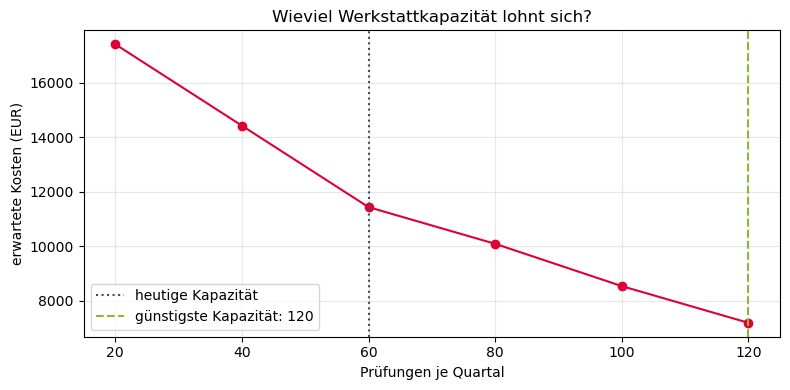

Mit 120 statt 60 Prüfungen liessen sich je Quartal rund 4.240 EUR sparen.


In [13]:
zeilen = []
for k in [20, 40, 60, 80, 100, 120]:
    e = liste_bewerten(f"Kapazität {k}", p_wald, y_test, kapazitaet=k)
    e["Kapazität"] = k
    zeilen.append(e)
kapazitaeten = pd.DataFrame(zeilen).set_index("Kapazität")
print(kapazitaeten[["Treffer", "Trefferquote", "unnötig geprüft",
                    "Ausfälle verpasst", "Kosten (EUR)"]].to_string())

plt.figure(figsize=(8, 4))
plt.plot(kapazitaeten.index, kapazitaeten["Kosten (EUR)"], marker="o", color="#e00034")
plt.axvline(KAPAZITAET, color="#3d4b6b", ls=":", label="heutige Kapazität")
guenstigste = kapazitaeten["Kosten (EUR)"].idxmin()
plt.axvline(guenstigste, color="#8AB833", ls="--", label=f"günstigste Kapazität: {guenstigste}")
plt.xlabel("Prüfungen je Quartal"); plt.ylabel("erwartete Kosten (EUR)")
plt.title("Wieviel Werkstattkapazität lohnt sich?"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

mehr = kapazitaeten.loc[KAPAZITAET, "Kosten (EUR)"] - kapazitaeten["Kosten (EUR)"].min()
print(f"Mit {guenstigste} statt {KAPAZITAET} Prüfungen liessen sich je Quartal "
      f"rund {mehr:,.0f} EUR sparen.".replace(",", "."))

**Das ist der Punkt, an dem aus einer Analyse eine Entscheidungsvorlage wird.** Die Frage
„sollen wir eine halbe Stelle in der Werkstatt aufbauen?" lässt sich jetzt mit einer Zahl
beantworten statt mit einem Gefühl — und zwar mit einer, die aus denselben Kosten
abgeleitet ist, die in Phase 1 festgelegt wurden.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Aus dem Modell wird eine Liste, die montags in der Werkstatt liegt.

In [14]:
import joblib, datetime

liste = test_zeilen.copy()
liste["risiko"] = p_wald
liste = liste.sort_values("risiko", ascending=False).head(KAPAZITAET)
liste["rang"] = range(1, len(liste) + 1)

ausgabe = liste[["rang", "rahmennummer", "typ_code", "risiko", "km_180", "fahrten_180",
                 "meldungen_bisher", "tage_seit_meldung"]].copy()
ausgabe["risiko"] = (ausgabe.risiko * 100).round(0).astype(int).astype(str) + " %"
ausgabe["km_180"] = ausgabe.km_180.round(0)
ausgabe = ausgabe.rename(columns={
    "rahmennummer": "Rahmennummer", "typ_code": "Typ", "risiko": "Risiko",
    "km_180": "km (180 Tage)", "fahrten_180": "Fahrten (180 Tage)",
    "meldungen_bisher": "Meldungen bisher", "tage_seit_meldung": "Tage seit letzter Meldung"})

print(f"WARTUNGSLISTE  Quartal ab {letzter.date()}   ({KAPAZITAET} Räder)\n")
print(ausgabe.head(15).to_string(index=False))
print(f"\n... und {len(ausgabe) - 15} weitere.")

ausgabe.to_csv("wartungsliste.csv", index=False)
joblib.dump({"modell": wald, "merkmalsspalten": list(X_alle.columns),
             "horizont_tage": HORIZONT_TAGE, "rueckblick_tage": RUECKBLICK_TAGE,
             "kapazitaet": KAPAZITAET, "trainiert_am": datetime.date.today().isoformat(),
             "trefferquote_test": round(trefferquote, 3)}, "wartungsmodell.joblib")
print("\ngeschrieben: wartungsliste.csv, wartungsmodell.joblib")

WARTUNGSLISTE  Quartal ab 2026-05-26   (60 Räder)

 rang Rahmennummer   Typ Risiko  km (180 Tage)  Fahrten (180 Tage)  Meldungen bisher  Tage seit letzter Meldung
    1     WUE-0123  CITY   92 %          120.0                24.0               1.0                      541.0
    2     WUE-0125 EBIKE   90 %          194.0                35.0               3.0                      286.0
    3     WUE-0148  CITY   90 %           97.0                25.0               0.0                     9999.0
    4     WUE-0103 EBIKE   90 %          151.0                32.0               0.0                     9999.0
    5     WUE-0133 EBIKE   89 %          125.0                28.0               0.0                     9999.0
    6     WUE-0020  CITY   89 %           99.0                26.0               2.0                      326.0
    7     WUE-0139  CITY   88 %          128.0                30.0               1.0                      333.0
    8     WUE-0039  CITY   88 %          375.0       


geschrieben: wartungsliste.csv, wartungsmodell.joblib


### 6.1 Diese Liste ist das eigentliche Produkt

Nicht das Modell, nicht die Confusion-Matrix — **diese Tabelle**. Sie ist so gebaut, dass
die Werkstatt sie ohne Nacharbeit übernehmen kann: Rahmennummer statt Datenbank-ID,
Risiko in Prozent statt als Fließkommazahl, und daneben die Zahlen, die die Einschätzung
begründen. Ein Meister, der Rad WUE-0087 für unbedenklich hält, sieht sofort, worauf sich
das Modell stützt, und kann widersprechen.

In der VeloCity-Warenwirtschaft (`wawi.butscher.cloud`) gehört diese Liste in den Bereich
**Instandhaltung**, als eigene Ansicht neben den gemeldeten Schäden.

### 6.2 Überwachung

| Wache | Schwelle | Reaktion |
|---|---|---|
| Trefferquote der letzten Quartalsliste | unter 60 % | nachtrainieren |
| Anteil positiver Fälle in der Flotte | weicht um mehr als 10 Punkte vom Trainingsstand ab | Modell passt nicht mehr zur Lage |
| Räder, die trotz Prüfung ausfallen | steigt | die Prüfung selbst greift zu kurz — kein Modellproblem |
| Neue Radtypen im Bestand | tauchen auf | Modell kennt sie nicht |

**Die dritte Zeile ist die wichtigste und wird fast immer vergessen.** Ein perfektes
Modell nützt nichts, wenn die Prüfung den Defekt nicht findet. Dann ist nicht die
Vorhersage falsch, sondern die Maßnahme — und kein Nachtrainieren der Welt hilft.

### 6.3 Die Rückkopplung, die dieses Modell besonders schwierig macht

Hier steckt eine Falle, die es in Notebook 1 nicht gab:

> **Sobald die Liste benutzt wird, verändert sie die Daten, aus denen sie lernt.**

Ein Rad, das vorsorglich geprüft und instandgesetzt wurde, meldet sich anschließend
*nicht*. Im nächsten Trainingslauf erscheint es damit als „unauffällig" — obwohl es
gerade deshalb unauffällig war, weil das Modell es erkannt hatte. Das Modell lernt
gegen sich selbst.

**Gegenmittel:** Die durchgeführten Prüfungen mitprotokollieren und beim Nachtrainieren
als Merkmal führen (`wurde_vorsorglich_geprueft`). Nur dann kann das Modell zwischen
„war nie gefährdet" und „wurde rechtzeitig gerettet" unterscheiden.

---

# Der Kreislauf schließt sich

| Phase | Ergebnis |
|---|---|
| 1 Business Understanding | Aus „vorausschauend warten" wurde eine Kostenmatrix: 180 € je verpasstem Ausfall gegen 25 € je unnötiger Prüfung — Verhältnis rund 7 : 1. Zwei Erfolgskriterien, eines davon der Vergleich mit der heutigen Faustregel |
| 2 Data Understanding | Nutzung und Meldungen hängen zusammen (r ≈ 0,7), aber nicht deterministisch. 47 % der Räder melden sich je Quartal, die Werkstatt schafft 26 % |
| 3 Data Preparation | Zeitlicher Schnitt statt Gesamtbetrachtung: Merkmale aus 180 Tagen davor, Label aus 90 Tagen danach, acht Stichtage, Testmenge ist der jüngste |
| 4 Modeling | Zuerst zwei Faustregeln als Maßstab, dann Baum und Wald — beide mit `class_weight` aus der Kostenmatrix |
| 5 Evaluation | **Der Sachverstand schlug das Verfahren:** „km seit letzter Meldung" bringt 80 % Treffer, der Random Forest 81,7 %. Der große Sprung lag vor dem Modell. Beide Erfolgskriterien erfüllt, Freigabe |
| 6 Deployment | Eine Wartungsliste mit Rahmennummern und Begründung, Überwachung, und die Rückkopplungsfalle |

**Was eine zweite Runde anders machen würde**

1. **Zurück zu Phase 1:** Nicht jede Meldung ist gleich schlimm. Ein Plattfuß kostet
   anderes als ein Bremsdefekt. Die Kostenmatrix müsste nach `schwere` aufgeschlüsselt
   werden — dann würde aus der Klassifikation eine Kostenminimierung mit drei Klassen.
2. **Zurück zu Phase 2:** Uns fehlt, was ein Rad *erlebt* hat: Stürze, Vandalismus,
   Standzeiten im Regen. Ein Rad an der Alten Mainbrücke wird anders beansprucht als
   eines am Hubland — die Startstationen des Rades wären ein Merkmal, das wir nicht
   verwendet haben.
3. **Zurück zu Phase 3:** Der Rückblick von 180 Tagen war gesetzt, nicht geprüft.
   Vielleicht sagen 60 Tage mehr über den nächsten Defekt aus als ein halbes Jahr.
4. **Die Jahreszeit ernst nehmen.** Der Anteil auffälliger Räder schwankt zwischen 9 %
   im November und 55 % im Mai. Eine feste Kapazität von 60 Prüfungen je Quartal ist
   dafür das falsche Werkzeug — sinnvoller wäre eine Schwelle auf der Risikozahl
   („alles über 60 % kommt in die Werkstatt"), die im Winter von selbst kürzere Listen
   erzeugt. Das ändert die Auslieferung, nicht das Modell.

**Weiter geht es mit Notebook 3 — Clustering und Segmentierung:** Dort gibt es zum ersten
Mal **kein Label**. Niemand sagt dem Verfahren, was richtig ist; es soll die Gruppen
selbst finden.